# Model 1 — Forecast Bias-Correction: In-Sample & Out-of-Sample Performance

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import evaluation

# ── Load predictions from parquet (generated by model1_forecast.py) ──
df_train = pd.read_parquet('checkpoints/model1_preds_train.parquet')
df_test = pd.read_parquet('checkpoints/model1_preds_test.parquet')

print(f'Train set: {len(df_train)} rows, {df_train.date.min().date()} to {df_train.date.max().date()}')
print(f'Test set:  {len(df_test)} rows, {df_test.date.min().date()} to {df_test.date.max().date()}')

Train set: 21919 rows, 2022-01-01 to 2024-12-31
Test set:  2120 rows, 2026-01-01 to 2026-04-16


## Overall Metrics: In-Sample (Train 2022-2024) vs Out-of-Sample (Test 2026)

In [2]:
train_metrics = evaluation.compute_metrics(df_train['y_true'].values, df_train['mu'].values)
test_metrics = evaluation.compute_metrics(df_test['y_true'].values, df_test['mu'].values)

metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    index=['In-Sample (Train 2022-2024)', 'Out-of-Sample (Test 2026)']
)
metrics_df.round(4)

,mae,rmse,bias,r2,corr,n
In-Sample (Train 2022-2024),1.0000,1.3808,-0.0454,0.9945,0.9972,21919
Out-of-Sample (Test 2026),1.1345,1.5433,-0.0428,0.9933,0.9966,2120


## Per-City Metrics (Out-of-Sample Test Set)

In [3]:
city_metrics = evaluation.metrics_by_city(df_test, y_true_col='y_true', y_pred_col='mu')
city_metrics.round(4)

,mae,rmse,bias,r2,corr,n,city,ticker
12,0.6656,0.8584,-0.4860,0.9951,0.9985,106,Las Vegas,KXHIGHTLV
16,0.8016,0.9954,0.2542,0.9916,0.9966,106,Phoenix,KXHIGHTPHX
9,0.8638,1.1060,-0.1384,0.9938,0.9969,106,Dallas,KXHIGHTDAL
15,0.8906,1.2113,-0.0487,0.9949,0.9978,106,Oklahoma City,KXHIGHTOKC
17,0.9400,1.4842,-0.1635,0.9845,0.9923,106,San Antonio,KXHIGHTSATX
14,0.9939,1.2913,0.2981,0.9854,0.9931,106,New Orleans,KXHIGHTNOLA
4,1.0037,1.3220,0.6129,0.9596,0.9842,106,Miami,KXHIGHMIA
7,1.0127,1.3057,-0.0601,0.9903,0.9953,106,Atlanta,KXHIGHTATL
11,1.0260,1.4034,0.0605,0.9830,0.9917,106,Houston,KXHIGHTHOU
18,1.0326,1.3487,0.0989,0.9488,0.9749,106,Seattle,KXHIGHTSEA


## Calibration Check (Out-of-Sample Test Set)

,target_coverage,actual_coverage
0,0.50,0.5052
1,0.68,0.6750
2,0.80,0.7835
3,0.90,0.8764
4,0.95,0.9255
5,0.99,0.9778


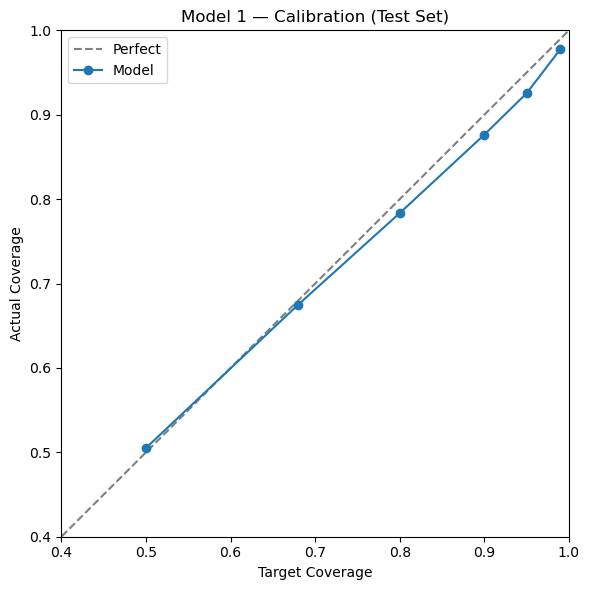

In [4]:
cal_df = evaluation.calibration_check(df_test['y_true'].values, df_test['mu'].values, df_test['sigma'].values)
display(cal_df.round(4))

fig = evaluation.plot_calibration(cal_df, title='Model 1 — Calibration (Test Set)')
plt.show()

## Residuals Histogram + Q-Q Plot

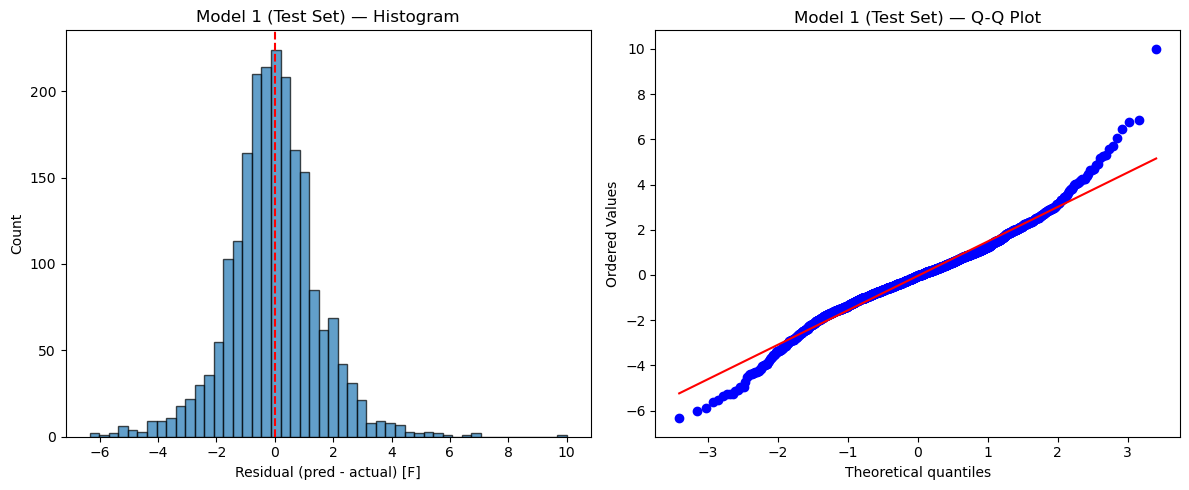

In [5]:
fig = evaluation.plot_residuals(df_test['y_true'].values, df_test['mu'].values, title='Model 1 (Test Set)')
plt.show()

## Time Series — NY, Phoenix, Miami

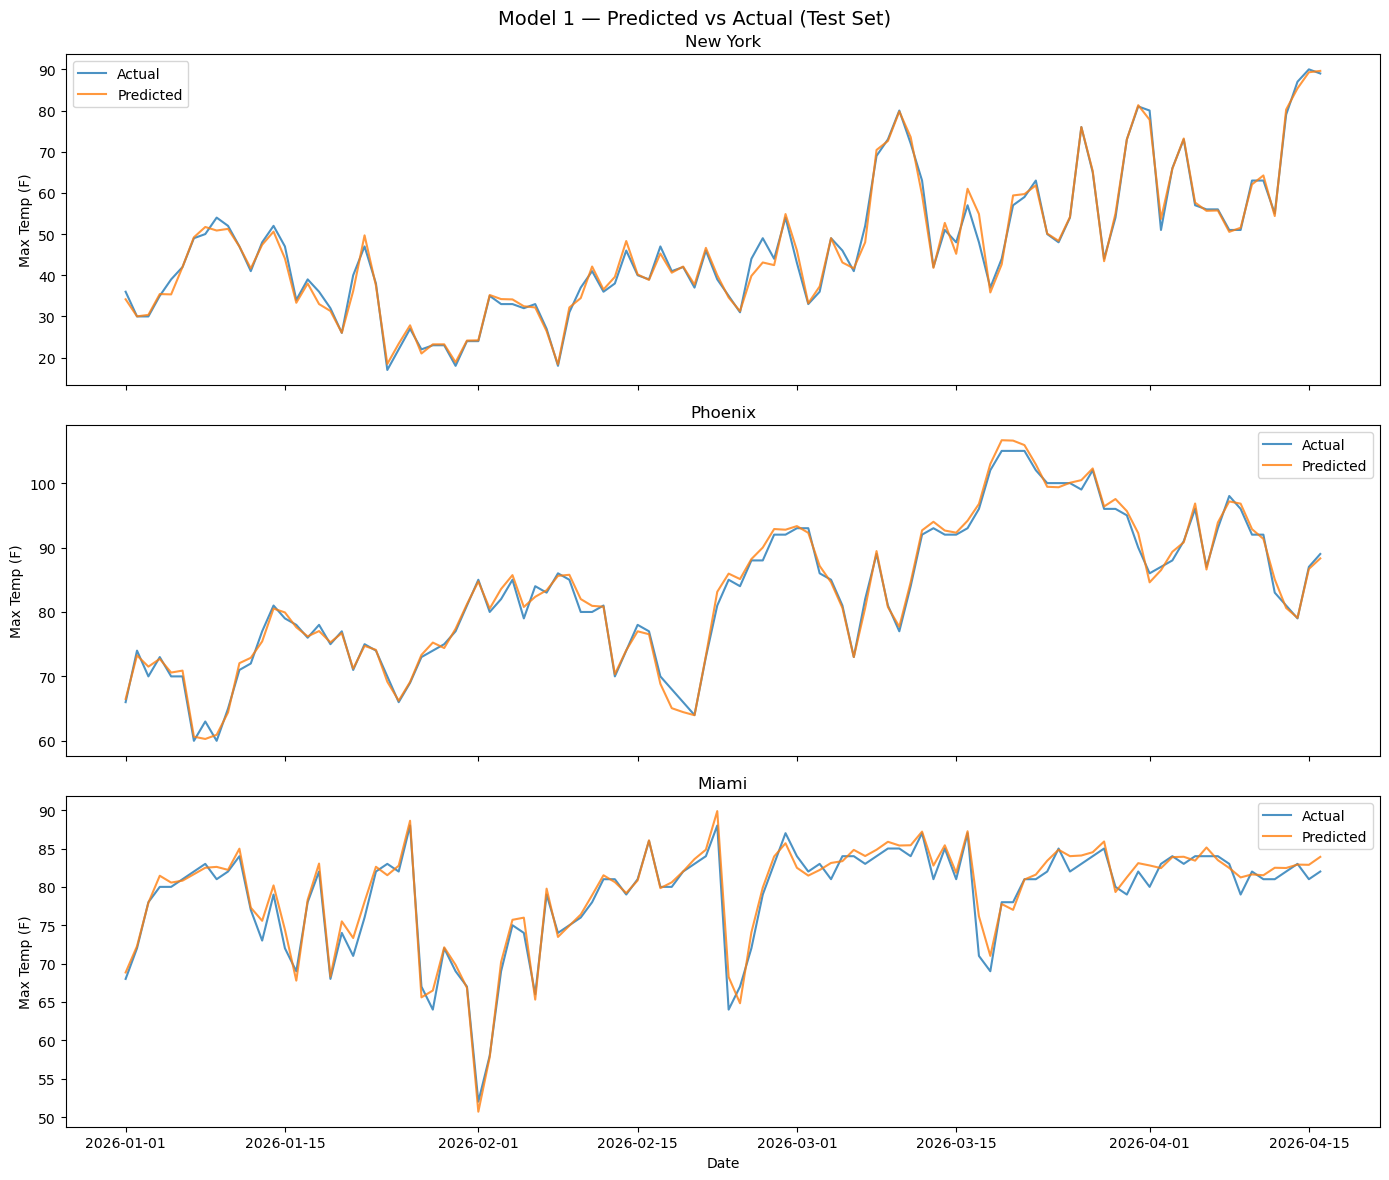

In [6]:
fig = evaluation.plot_timeseries(
    df_test, y_true_col='y_true', y_pred_col='mu',
    cities=['KXHIGHNY', 'KXHIGHTPHX', 'KXHIGHMIA'],
    title='Model 1 — Predicted vs Actual (Test Set)'
)
plt.show()

## MAE Heatmap by City and Month

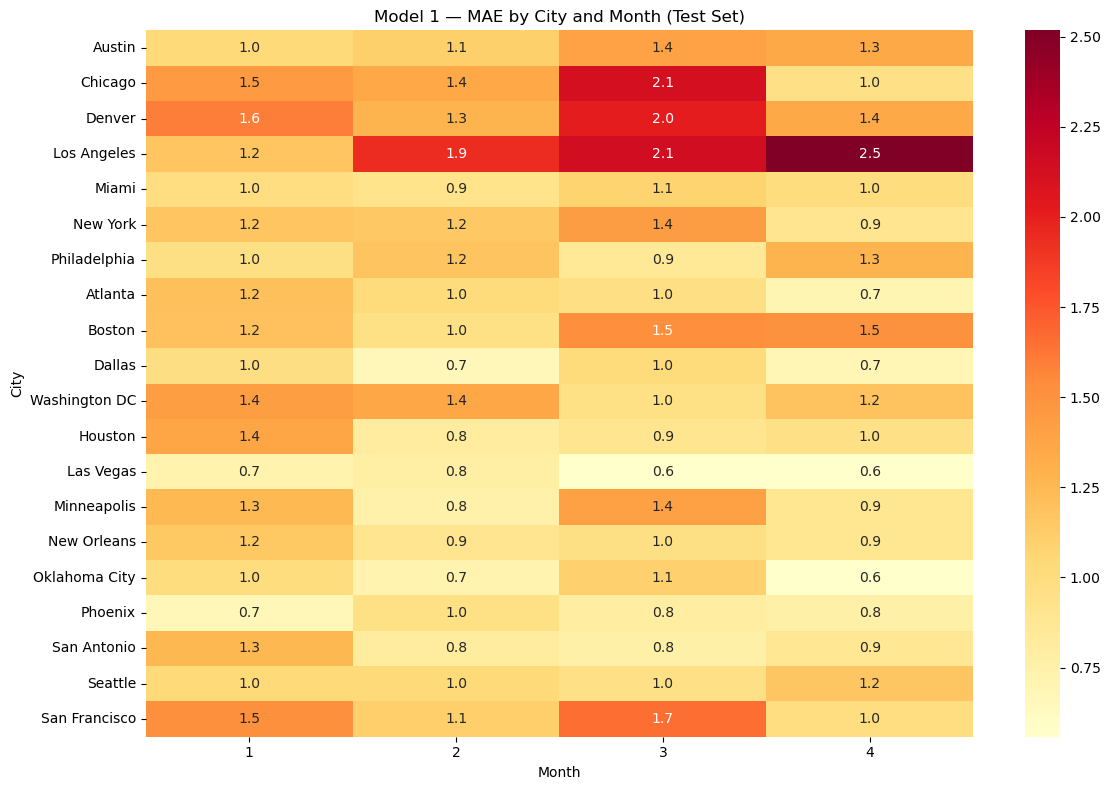

In [7]:
fig = evaluation.plot_mae_heatmap(
    df_test, y_true_col='y_true', y_pred_col='mu',
    title='Model 1 — MAE by City and Month (Test Set)'
)
plt.show()